# 06 — CD8+ T Cell Holdout Evaluation (3 Models)

**Three models compared:**
1. **scGen** — vector addition baseline (encode → shift δ → decode)
2. **IMPACT-OR** — CellOT with condition=species (mouse/human), holdout=CD8 cell type
3. **CellOT** — CellOT with condition=cell_type_status (cd8/non_cd8), holdout=human species

**Strict OOD:** scGen trained on ~104K cells **excluding CD8+**. Both IMPACT-OR and CellOT use frozen scGen encoder.

**Results path**: `cellot/cellot_gpu/results/speciesot_cd8/`

## 1. Check Training Status and Load Scalars

In [65]:
import sys
sys.path.insert(0, "/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata
import scanpy as sc
from pathlib import Path
from scipy.spatial.distance import cdist
from scipy import sparse
import pickle
import h5py

# Use the cellot_gpu results path if available, otherwise fall back to repo-local copy
_cellot_results = Path("/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/results/speciesot_cd8")
_repo_results = Path("../results/speciesot_cd8")  # relative to this notebook
RESULTS = _cellot_results if _cellot_results.exists() else _repo_results

IMPACT_OR_DIR = RESULTS / "impact_or"
CELLOT_DIR = RESULTS / "cellot"
SCGEN_DIR = RESULTS / "speciesot_scgen"

HOLDOUT_CELLTYPE = "CL:0000625"  # CD8-positive, alpha-beta T cell
SOURCE = "mouse"  # source species
TARGET = "human"  # target species

for name, d in [("scGen", SCGEN_DIR), ("IMPACT-OR", IMPACT_OR_DIR), ("CellOT", CELLOT_DIR)]:
    status_file = d / "cache/status"
    if status_file.exists():
        print(f"{name} status: {status_file.read_text().strip()}")
    else:
        print(f"{name} status: NOT STARTED or cache missing")

scGen status: done
IMPACT-OR status: done
CellOT status: done


In [66]:
def load_scalars(cache_dir):
    """Load CellOT/SCGen training scalars from HDF5 (pandas PyTables format)."""
    path = cache_dir / "cache" / "scalars"
    if not path.exists():
        print(f"  Scalars not found: {path}")
        return None
    out = {}
    with h5py.File(path, "r") as f:
        grp = "train" if "train" in f else list(f.keys())[0]
        t = f[grp]["table"]
        arr = t[:]
        steps = np.asarray(arr["index"])
        vals = np.asarray(arr["values_block_0"])
        kind = t.attrs.get("values_block_0_kind", b"")
        try:
            names = pickle.loads(kind) if kind else []
        except Exception:
            names = [f"col_{i}" for i in range(vals.shape[1] if vals.ndim > 1 else 1)]
        if vals.ndim == 1:
            vals = vals.reshape(-1, 1)
        for i, name in enumerate(names):
            if i < vals.shape[1]:
                out[name] = vals[:, i]
        out["step"] = steps
    return out

scgen_scalars = load_scalars(SCGEN_DIR)
impact_or_scalars = load_scalars(IMPACT_OR_DIR)
cellot_scalars = load_scalars(CELLOT_DIR)

if scgen_scalars:
    print("scGen scalar keys:", list(scgen_scalars.keys())[:10])
if impact_or_scalars:
    print("IMPACT-OR scalar keys:", list(impact_or_scalars.keys())[:10])
if cellot_scalars:
    print("CellOT scalar keys:", list(cellot_scalars.keys())[:10])

scGen scalar keys: ['loss', 'mse', 'reg', 'step']
IMPACT-OR scalar keys: ['gloss', 'floss', 'step']
CellOT scalar keys: ['gloss', 'floss', 'step']


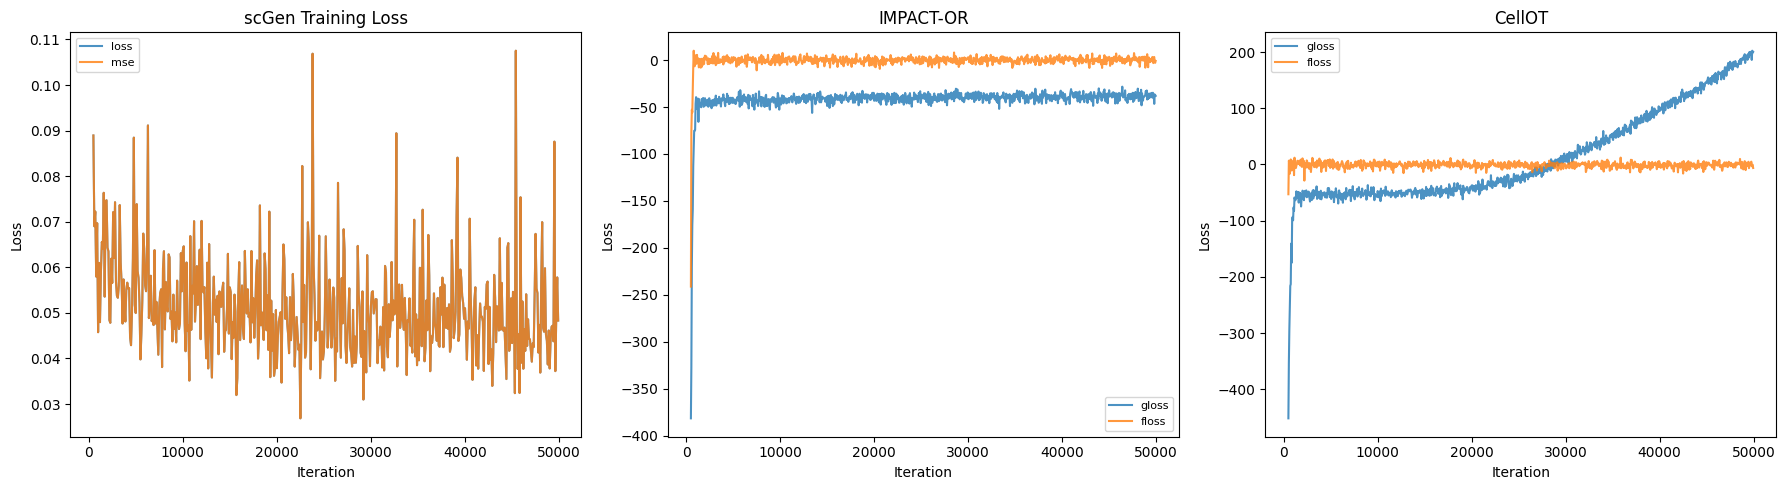

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Skip early iterations to remove initial spikes from CellOT
CLIP_START = 500

for idx, (scalars, title) in enumerate([
    (scgen_scalars, "scGen Training Loss"),
    (impact_or_scalars, "IMPACT-OR"),
    (cellot_scalars, "CellOT"),
]):
    ax = axes[idx]
    if scalars is None:
        ax.text(0.5, 0.5, "Not available yet", ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        continue
    x = scalars.get('step', np.arange(10))
    for k, v in scalars.items():
        if k != 'step' and ('loss' in k.lower() or 'mse' in k.lower() or 'obj' in k.lower()):
            mask = x[:len(v)] >= CLIP_START
            ax.plot(x[:len(v)][mask], v[mask], label=k, alpha=0.8)
    ax.legend(fontsize=8)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss")
    ax.set_title(title)

plt.tight_layout()
plt.show()

## 2. Run OOD Evaluation (if not done via sbatch)

If the CellOT evaluation script has already been run via sbatch, skip this cell.
Otherwise, run the evaluation inline.

In [68]:
eval_dir = IMPACT_OR_DIR / "evals_ood_data_space"
if (eval_dir / "imputed.h5ad").exists():
    print(f"IMPACT-OR evaluation exists: {eval_dir}")
    imputed_data = anndata.read_h5ad(eval_dir / "imputed.h5ad")
    print(f"Imputed shape: {imputed_data.shape}")
else:
    print("IMPACT-OR evaluation not found.")

IMPACT-OR evaluation exists: /n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/results/speciesot_cd8/impact_or/evals_ood_data_space
Imputed shape: (195, 1000)


## 3. Load Ground Truth and Compute Metrics

In [69]:
_cellot_data = Path("/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/datasets/speciesot-human-mouse/cd8_holdout_v07.h5ad")
_repo_data = Path("../results/speciesot_cd8/datasets/cd8_holdout_v07.h5ad")
DATA_PATH = str(_cellot_data if _cellot_data.exists() else _repo_data)
full_data = anndata.read_h5ad(DATA_PATH)
print(f"Full dataset: {full_data.shape}")

target_cd8 = full_data[
    (full_data.obs['condition'].astype(str).str.strip() == TARGET) &
    (full_data.obs['cell_type_ontology_term_id'].astype(str).str.strip() == HOLDOUT_CELLTYPE)
]
source_cd8 = full_data[
    (full_data.obs['condition'].astype(str).str.strip() == SOURCE) &
    (full_data.obs['cell_type_ontology_term_id'].astype(str).str.strip() == HOLDOUT_CELLTYPE)
]

print(f"\nSource ({SOURCE}) CD8+ T cells: {source_cd8.n_obs}")
print(f"Target ({TARGET}) CD8+ T cells (ground truth): {target_cd8.n_obs}")

eval_dir = IMPACT_OR_DIR / "evals_ood_data_space"
if (eval_dir / "imputed.h5ad").exists():
    imputed_data = anndata.read_h5ad(eval_dir / "imputed.h5ad")
    print(f"Imputed (predicted) cells: {imputed_data.n_obs}")
else:
    print("\nWARNING: imputed.h5ad not found. Run evaluation first.")

Full dataset: (12836, 1000)

Source (mouse) CD8+ T cells: 195
Target (human) CD8+ T cells (ground truth): 195
Imputed (predicted) cells: 195


In [70]:
def to_dense(X):
    if sparse.issparse(X):
        return np.array(X.todense())
    return np.array(X)

def compute_ood_metrics(treated_adata, imputed_adata):
    """Compute standard OOD evaluation metrics between ground truth and predictions."""
    treated = pd.DataFrame(to_dense(treated_adata.X), columns=treated_adata.var_names)
    imputed = pd.DataFrame(to_dense(imputed_adata.X), columns=imputed_adata.var_names)

    shared_genes = treated.columns.intersection(imputed.columns)
    treated = treated[shared_genes]
    imputed = imputed[shared_genes]

    metrics = {}

    mut = treated.mean(0)
    mui = imputed.mean(0)
    metrics['r2_means'] = pd.Series.corr(mut, mui) ** 2 if pd.Series.corr(mut, mui) == pd.Series.corr(mut, mui) else 0.0

    st = treated.std(0)
    si = imputed.std(0)
    metrics['r2_stds'] = pd.Series.corr(st, si) ** 2 if pd.Series.corr(st, si) == pd.Series.corr(st, si) else 0.0

    metrics['l2_means'] = np.linalg.norm(mut.values - mui.values)
    metrics['l2_stds'] = np.linalg.norm(st.values - si.values)

    try:
        corr_t = treated.corr()
        corr_i = imputed.corr()
        triu = np.triu_indices(corr_t.shape[0], k=1)
        r = np.corrcoef(corr_t.values[triu], corr_i.values[triu])[0, 1]
        metrics['r2_pairwise_feat_corrs'] = r ** 2 if r == r else float('nan')
    except Exception:
        metrics['r2_pairwise_feat_corrs'] = float('nan')

    from cellot.losses.mmd import mmd_distance
    gammas = np.logspace(-3, 3, num=50)
    mmd_vals = [mmd_distance(treated.values, imputed.values, g) for g in gammas]
    metrics['mmd'] = np.mean(mmd_vals)

    from sklearn.neighbors import NearestNeighbors
    combined = np.vstack([treated.values, imputed.values])
    labels = np.array([0] * treated.shape[0] + [1] * imputed.shape[0])
    for k in [50, 51]:
        if k >= combined.shape[0]:
            k = combined.shape[0] - 1
        nn = NearestNeighbors(n_neighbors=k).fit(combined)
        _, indices = nn.kneighbors(combined)
        same_label = np.mean([np.mean(labels[indices[i, 1:]] == labels[i]) for i in range(len(labels))])
        metrics[f'enrichment_k{k}'] = same_label

    return metrics

In [71]:
eval_dir = IMPACT_OR_DIR / "evals_ood_data_space"
if (eval_dir / "imputed.h5ad").exists():
    imputed_data = anndata.read_h5ad(eval_dir / "imputed.h5ad")
    metrics = compute_ood_metrics(target_cd8, imputed_data)

    print("=" * 70)
    print(f"SPECIESOT: Held-Out CD8+ T Cell ({HOLDOUT_CELLTYPE}) Evaluation Summary")
    print(f"Model: IMPACT-OR + scGen encoder")
    print(f"Direction: {SOURCE} → {TARGET}")
    print(f"OOD cells: {imputed_data.n_obs}")
    print("=" * 70)

    summary = pd.DataFrame([
        ("r2_means", metrics['r2_means'], "1.0 = perfect mean match"),
        ("r2_stds", metrics['r2_stds'], "1.0 = perfect variability match"),
        ("l2_means", metrics['l2_means'], "0.0 = perfect (lower is better)"),
        ("l2_stds", metrics['l2_stds'], "0.0 = perfect (lower is better)"),
        ("r2_pairwise_feat_corrs", metrics.get('r2_pairwise_feat_corrs', float('nan')), "1.0 = gene-gene correlations preserved"),
        ("mmd", metrics['mmd'], "0.0 = distributions identical"),
        ("enrichment_k50", metrics.get('enrichment_k50', float('nan')), "0.5 = perfect mixing"),
        ("enrichment_k51", metrics.get('enrichment_k51', float('nan')), "0.5 = perfect mixing"),
    ], columns=["Metric", "Value", "Interpretation"])
    display(summary)
else:
    print("Evaluation not available yet. Run CellOT evaluation first.")

SPECIESOT: Held-Out CD8+ T Cell (CL:0000625) Evaluation Summary
Model: IMPACT-OR + scGen encoder
Direction: mouse → human
OOD cells: 195


,Metric,Value,Interpretation
0,r2_means,0.717761,1.0 = perfect mean match
1,r2_stds,0.322732,1.0 = perfect variability match
2,l2_means,0.695422,0.0 = perfect (lower is better)
3,l2_stds,2.647480,0.0 = perfect (lower is better)
4,r2_pairwise_feat_corrs,NaN,1.0 = gene-gene correlations preserved
5,mmd,0.052424,0.0 = distributions identical
6,enrichment_k50,0.513239,0.5 = perfect mixing
7,enrichment_k51,0.513179,0.5 = perfect mixing


## 4. UMAP Visualization

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


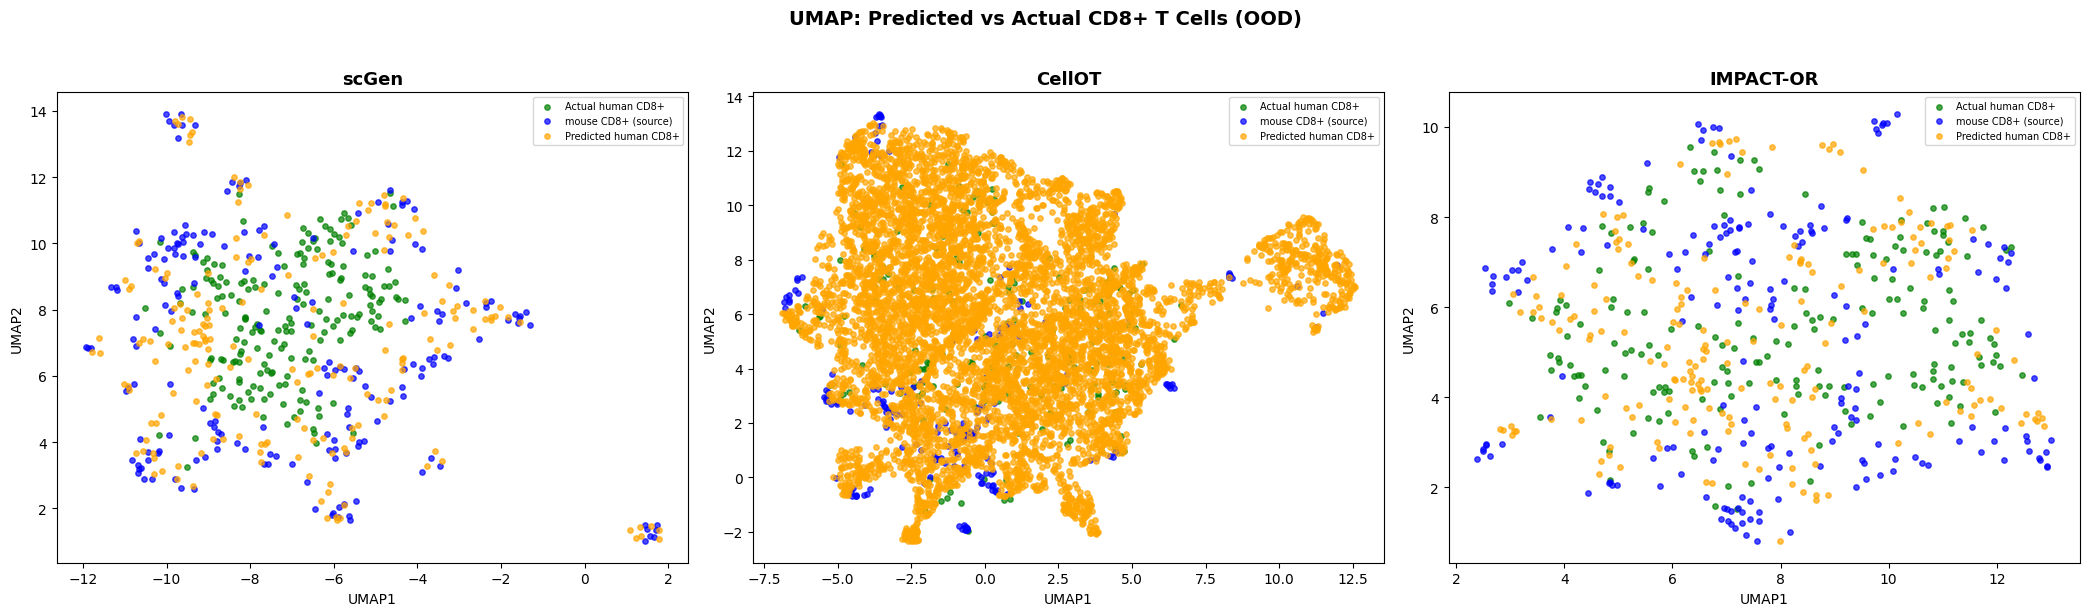

In [72]:
# Collect imputed data for each model
umap_models = {}

# scGen (from section 7)
if 'scgen_imputed' in dir():
    umap_models['scGen'] = to_dense(scgen_imputed.X)

# CellOT
cellot_path = CELLOT_DIR / 'evals_ood_data_space' / 'imputed.h5ad'
if cellot_path.exists():
    umap_models['CellOT'] = to_dense(anndata.read_h5ad(cellot_path).X)

# IMPACT-OR
impact_or_path = IMPACT_OR_DIR / 'evals_ood_data_space' / 'imputed.h5ad'
if impact_or_path.exists():
    umap_models['IMPACT-OR'] = to_dense(anndata.read_h5ad(impact_or_path).X)

n_models = len(umap_models)
if n_models == 0:
    print('No model predictions available yet for UMAP.')
else:
    treated_X = to_dense(target_cd8.X)
    source_X = to_dense(source_cd8.X)
    n_t = treated_X.shape[0]
    n_s = source_X.shape[0]

    fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 6))
    if n_models == 1:
        axes = [axes]

    for ax, (model_name, imputed_X) in zip(axes, umap_models.items()):
        n_i = imputed_X.shape[0]
        combined = np.vstack([treated_X, source_X, imputed_X])

        umap_adata = anndata.AnnData(X=combined)
        sc.pp.pca(umap_adata, n_comps=min(30, combined.shape[0] - 1, combined.shape[1] - 1))
        sc.pp.neighbors(umap_adata)
        sc.tl.umap(umap_adata)
        coords = umap_adata.obsm['X_umap']

        ax.scatter(coords[:n_t, 0], coords[:n_t, 1], s=15, alpha=0.7, c='green', label=f'Actual {TARGET} CD8+')
        ax.scatter(coords[n_t:n_t+n_s, 0], coords[n_t:n_t+n_s, 1], s=15, alpha=0.7, c='blue', label=f'{SOURCE} CD8+ (source)')
        ax.scatter(coords[n_t+n_s:, 0], coords[n_t+n_s:, 1], s=15, alpha=0.7, c='orange', label=f'Predicted {TARGET} CD8+')

        ax.set_xlabel('UMAP1')
        ax.set_ylabel('UMAP2')
        ax.set_title(model_name, fontsize=13, fontweight='bold')
        ax.legend(loc='best', fontsize=7)

    plt.suptitle(f'UMAP: Predicted vs Actual CD8+ T Cells (OOD)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## 5. Gene Expression Scatter Plots

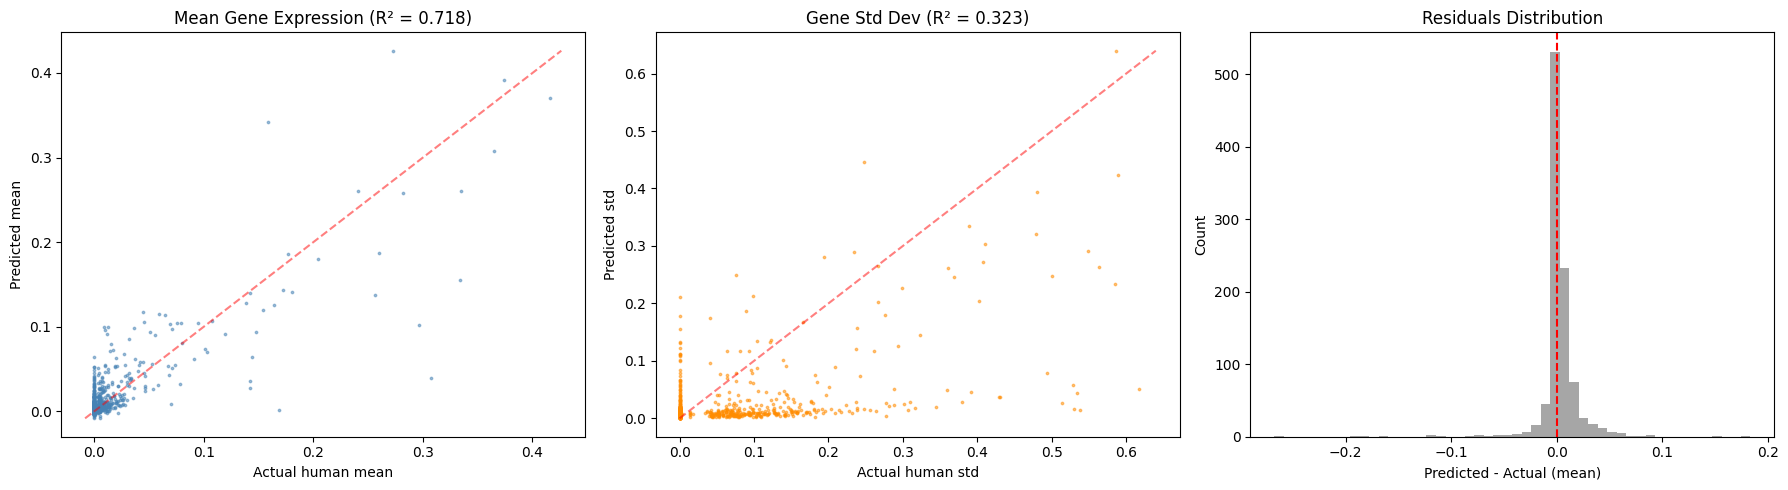

In [73]:
eval_dir = IMPACT_OR_DIR / "evals_ood_data_space"
if (eval_dir / "imputed.h5ad").exists():
    imputed_data = anndata.read_h5ad(eval_dir / "imputed.h5ad")

    treated = pd.DataFrame(to_dense(target_cd8.X), columns=target_cd8.var_names)
    imputed = pd.DataFrame(to_dense(imputed_data.X), columns=imputed_data.var_names)
    shared_genes = treated.columns.intersection(imputed.columns)
    treated = treated[shared_genes]
    imputed = imputed[shared_genes]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    mut = treated.mean(0).values
    mui = imputed.mean(0).values
    r2m = metrics['r2_means']
    axes[0].scatter(mut, mui, s=3, alpha=0.5, c='steelblue')
    lims = [min(mut.min(), mui.min()), max(mut.max(), mui.max())]
    axes[0].plot(lims, lims, 'r--', alpha=0.5)
    axes[0].set_xlabel(f'Actual {TARGET} mean')
    axes[0].set_ylabel('Predicted mean')
    axes[0].set_title(f'Mean Gene Expression (R² = {r2m:.3f})')

    st = treated.std(0).values
    si = imputed.std(0).values
    r2s = metrics['r2_stds']
    axes[1].scatter(st, si, s=3, alpha=0.5, c='darkorange')
    lims = [min(st.min(), si.min()), max(st.max(), si.max())]
    axes[1].plot(lims, lims, 'r--', alpha=0.5)
    axes[1].set_xlabel(f'Actual {TARGET} std')
    axes[1].set_ylabel('Predicted std')
    axes[1].set_title(f'Gene Std Dev (R² = {r2s:.3f})')

    residuals = mui - mut
    axes[2].hist(residuals, bins=50, alpha=0.7, color='gray')
    axes[2].axvline(0, color='r', linestyle='--')
    axes[2].set_xlabel('Predicted - Actual (mean)')
    axes[2].set_ylabel('Count')
    axes[2].set_title('Residuals Distribution')

    plt.tight_layout()
    plt.show()
else:
    print("Evaluation not available yet.")

## 7. scGen-as-Baseline (Vector Addition) Evaluation

scGen predicts by: `decode(encode(source_cell) + δ)` where `δ = mean(target_latent) - mean(source_latent)`.

**Strict OOD:** The encoder/decoder was trained on ~104K cells **excluding CD8+**. The species shift δ is also computed from non-CD8 cells only. CD8 cells are completely unseen by scGen — both the encoder AND the shift.

In [74]:
import collections
import collections.abc
# Patch for Python 3.10+: MutableMapping moved to collections.abc
if not hasattr(collections, 'MutableMapping'):
    collections.MutableMapping = collections.abc.MutableMapping

import torch
from cellot.utils.loaders import load_model, resolve_device
from cellot.utils import load_config

scgen_config = load_config(SCGEN_DIR / "config.yaml")
scgen_device = resolve_device(scgen_config)

scgen_model, _ = load_model(
    scgen_config,
    restore=SCGEN_DIR / "cache" / "model.pt",
    device=scgen_device,
    input_dim=full_data.n_vars,
)
scgen_model.eval()
print(f"scGen model loaded from {SCGEN_DIR}")
print(f"  Input dim: {full_data.n_vars}, Latent dim: {scgen_config.model.latent_dim}")
print(f"  Device: {scgen_device}")

scGen model loaded from /n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/results/speciesot_cd8/speciesot_scgen
  Input dim: 1000, Latent dim: 50
  Device: cpu


In [75]:
# Compute species shift from NON-CD8 training cells only
train_cells = full_data[
    full_data.obs['cell_type_ontology_term_id'].astype(str).str.strip() != HOLDOUT_CELLTYPE
]
print(f"Training cells (non-CD8): {train_cells.n_obs}")

train_source = train_cells[train_cells.obs['condition'].astype(str).str.strip() == SOURCE]
train_target = train_cells[train_cells.obs['condition'].astype(str).str.strip() == TARGET]
print(f"  Source ({SOURCE}): {train_source.n_obs}")
print(f"  Target ({TARGET}): {train_target.n_obs}")

with torch.no_grad():
    source_latent = scgen_model.encode(torch.tensor(to_dense(train_source.X), dtype=torch.float32).to(scgen_device))
    target_latent = scgen_model.encode(torch.tensor(to_dense(train_target.X), dtype=torch.float32).to(scgen_device))

delta = target_latent.mean(0) - source_latent.mean(0)
print(f"\nSpecies shift δ: shape={delta.shape}, norm={torch.norm(delta).item():.4f}")

Training cells (non-CD8): 12446
  Source (mouse): 6223
  Target (human): 6223

Species shift δ: shape=torch.Size([50]), norm=4.1078


In [76]:
# Predict target CD8+ cells from source CD8+ cells via vector addition
source_cd8_X = torch.tensor(to_dense(source_cd8.X), dtype=torch.float32).to(scgen_device)

with torch.no_grad():
    source_cd8_latent = scgen_model.encode(source_cd8_X)
    predicted_latent = source_cd8_latent + delta
    predicted_X = scgen_model.decode(predicted_latent).cpu().numpy()

scgen_imputed = anndata.AnnData(
    X=predicted_X,
    var=pd.DataFrame(index=full_data.var_names),
)
print(f"scGen predicted shape: {scgen_imputed.shape}")
print(f"Ground truth target CD8+ shape: {target_cd8.shape}")

scgen_metrics = compute_ood_metrics(target_cd8, scgen_imputed)

print(f"\nscGen-as-baseline OOD metrics:")
for k, v in scgen_metrics.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) and v == v else f"  {k}: {v}")

scGen predicted shape: (195, 1000)
Ground truth target CD8+ shape: (195, 1000)

scGen-as-baseline OOD metrics:
  r2_means: 0.5498
  r2_stds: 0.1759
  l2_means: 1.0077381134033203
  l2_stds: 4.093467712402344
  r2_pairwise_feat_corrs: nan
  mmd: 0.018677156418561935
  enrichment_k50: 0.5088
  enrichment_k51: 0.5087


## 8. Load All Three Models' Predictions

Collect metrics from: scGen (already computed above), IMPACT-OR, CellOT.

In [77]:
all_model_metrics = {'scGen': scgen_metrics}

# CellOT
cellot_eval = CELLOT_DIR / "evals_ood_data_space" / "imputed.h5ad"
if cellot_eval.exists():
    imp_s = anndata.read_h5ad(cellot_eval)
    all_model_metrics['CellOT'] = compute_ood_metrics(target_cd8, imp_s)
    print(f"CellOT loaded: {imp_s.shape}")
else:
    print("CellOT: not evaluated yet")

# IMPACT-OR
impact_or_eval = IMPACT_OR_DIR / "evals_ood_data_space" / "imputed.h5ad"
if impact_or_eval.exists():
    imp = anndata.read_h5ad(impact_or_eval)
    all_model_metrics['IMPACT-OR'] = compute_ood_metrics(target_cd8, imp)
    print(f"IMPACT-OR loaded: {imp.shape}")
else:
    print("IMPACT-OR: not evaluated yet")

print(f"\nModels with metrics: {list(all_model_metrics.keys())}")

CellOT loaded: (6223, 1000)
IMPACT-OR loaded: (195, 1000)

Models with metrics: ['scGen', 'CellOT', 'IMPACT-OR']


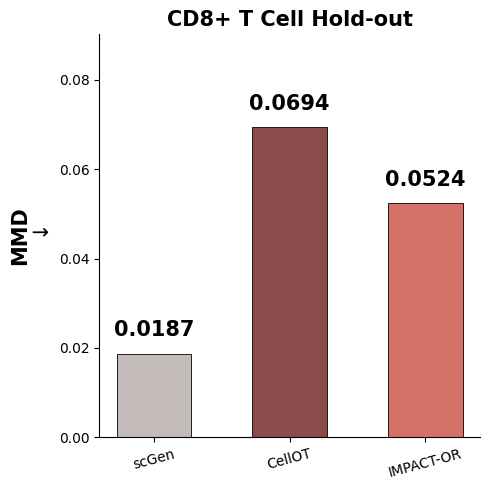

Saved: /n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/results/speciesot_cd8/mmd_bar_graph_cd8_ood.png


In [78]:
# ==========================================================================
# GRAPH 1: MMD Bar Graph (imitating CellOT paper Fig 4f bottom panel)
# ==========================================================================
model_names = list(all_model_metrics.keys())
mmd_values = [all_model_metrics[m]['mmd'] for m in model_names]

colors_map = {'scGen': '#C3BABA', 'CellOT': '#8B4B4B', 'IMPACT-OR': '#D4726A'}
colors = [colors_map.get(m, '#999999') for m in model_names]

fig, ax = plt.subplots(figsize=(5, 5))
bars = ax.bar(model_names, mmd_values, color=colors, width=0.55, edgecolor='black', linewidth=0.6)

for bar, val in zip(bars, mmd_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=15, fontweight='bold')

ax.set_ylabel('MMD\n$\\downarrow$', fontsize=15, fontweight='bold')
ax.set_title('CD8+ T Cell Hold-out', fontsize=15, fontweight='bold')
ax.set_ylim(0, max(mmd_values) * 1.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', rotation=15)

missing = [m for m in ['scGen', 'IMPACT-OR', 'CellOT'] if m not in all_model_metrics]
if missing:
    ax.text(0.95, 0.95, f'Missing: {", ".join(missing)}',
            transform=ax.transAxes, ha='right', va='top', fontsize=15, style='italic', color='gray')

plt.tight_layout()
plt.savefig(str(RESULTS / 'mmd_bar_graph_cd8_ood.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {RESULTS / 'mmd_bar_graph_cd8_ood.png'}")

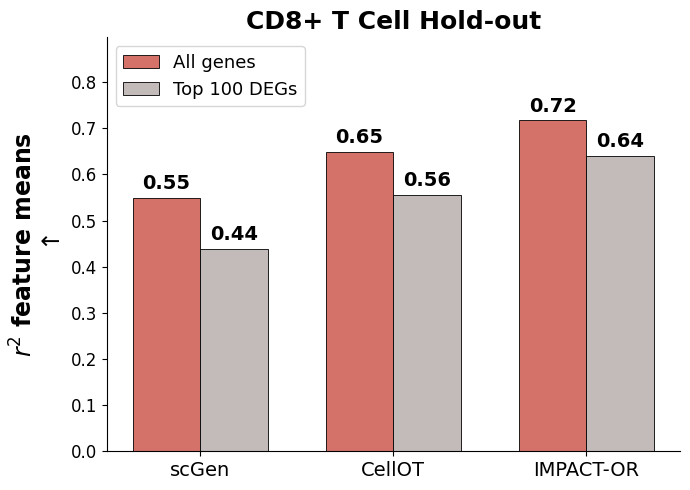

Saved: /n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/results/speciesot_cd8/r2_bar_graph_cd8_ood.png


In [79]:
# ==========================================================================
# GRAPH 3: R-squared Grouped Bar Graph (all genes + top 100 DEGs)
# ==========================================================================
# First, compute top-100-DEG R2 for each model
treated_df_r2 = pd.DataFrame(to_dense(target_cd8.X), columns=target_cd8.var_names)
actual_means_r2 = treated_df_r2.mean(0)
gene_var_r2 = treated_df_r2.var(0)
top_100_degs_r2 = gene_var_r2.nlargest(100).index.tolist()

model_names = list(all_model_metrics.keys())
r2_all = [all_model_metrics[m]['r2_means'] for m in model_names]

# Compute top-100-DEG R2 for each model
r2_deg = []
for mname in model_names:
    if mname == 'scGen':
        pred = pd.DataFrame(to_dense(scgen_imputed.X), columns=scgen_imputed.var_names).mean(0)
    elif mname == 'IMPACT-OR' and impact_or_eval.exists():
        pred = pd.DataFrame(to_dense(anndata.read_h5ad(impact_or_eval).X), columns=target_cd8.var_names).mean(0)
    elif mname == 'CellOT' and cellot_eval.exists():
        pred = pd.DataFrame(to_dense(anndata.read_h5ad(cellot_eval).X), columns=anndata.read_h5ad(cellot_eval).var_names).mean(0)
    else:
        r2_deg.append(0)
        continue
    shared = actual_means_r2.index.intersection(pred.index)
    is_deg_mask = np.array([g in top_100_degs_r2 for g in shared])
    x_deg = pred[shared].values[is_deg_mask]
    y_deg = actual_means_r2[shared].values[is_deg_mask]
    r = np.corrcoef(x_deg, y_deg)[0, 1] if len(x_deg) > 2 else 0
    r2_deg.append(r ** 2 if r == r else 0)

x_pos = np.arange(len(model_names))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
bars1 = ax.bar(x_pos - bar_width/2, r2_all, bar_width, label='All genes',
               color='#D4726A', edgecolor='black', linewidth=0.6)
bars2 = ax.bar(x_pos + bar_width/2, r2_deg, bar_width, label='Top 100 DEGs',
               color='#C3BABA', edgecolor='black', linewidth=0.6)

for bar, val in zip(bars1, r2_all):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontsize=14, fontweight='bold')
for bar, val in zip(bars2, r2_deg):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_ylabel('$r^2$ feature means\n$\\uparrow$', fontsize=17, fontweight='bold')
ax.set_title('CD8+ T Cell Hold-out', fontsize=18, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, fontsize=14)
ax.set_ylim(0, max(max(r2_all), max(r2_deg)) * 1.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=13)

plt.tight_layout()
plt.savefig(str(RESULTS / 'r2_bar_graph_cd8_ood.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {RESULTS / 'r2_bar_graph_cd8_ood.png'}")

In [80]:
# ==========================================================================
# FULL COMPARISON TABLE — All 3 Models
# ==========================================================================
metric_keys = ['r2_means', 'r2_stds', 'l2_means', 'l2_stds', 'mmd', 'enrichment_k50']
ideal_vals = [1.0, 1.0, 0.0, 0.0, 0.0, 0.5]

comp = {'Metric': metric_keys, 'Ideal': ideal_vals}
for model_name, m in all_model_metrics.items():
    comp[model_name] = [m.get(k, float('nan')) for k in metric_keys]

comparison_df = pd.DataFrame(comp)
print("=" * 80)
print("Full Comparison — CD8+ T Cell OOD")
print("=" * 80)
display(comparison_df)

Full Comparison — CD8+ T Cell OOD


,Metric,Ideal,scGen,CellOT,IMPACT-OR
0,r2_means,1.0,0.549810,0.648786,0.717761
1,r2_stds,1.0,0.175948,0.281415,0.322732
2,l2_means,0.0,1.007738,0.762567,0.695422
3,l2_stds,0.0,4.093468,2.793134,2.647480
4,mmd,0.0,0.018677,0.069375,0.052424
5,enrichment_k50,0.5,0.508844,0.969801,0.513239


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


Top 10 DEG labels: ['TPRG1', 'UFM1', 'MTFR1', 'CALCOCO2', 'RNASEH2B', 'XRRA1', 'PTGDR', 'USP9Y', 'SLC4A10', 'TRANK1']


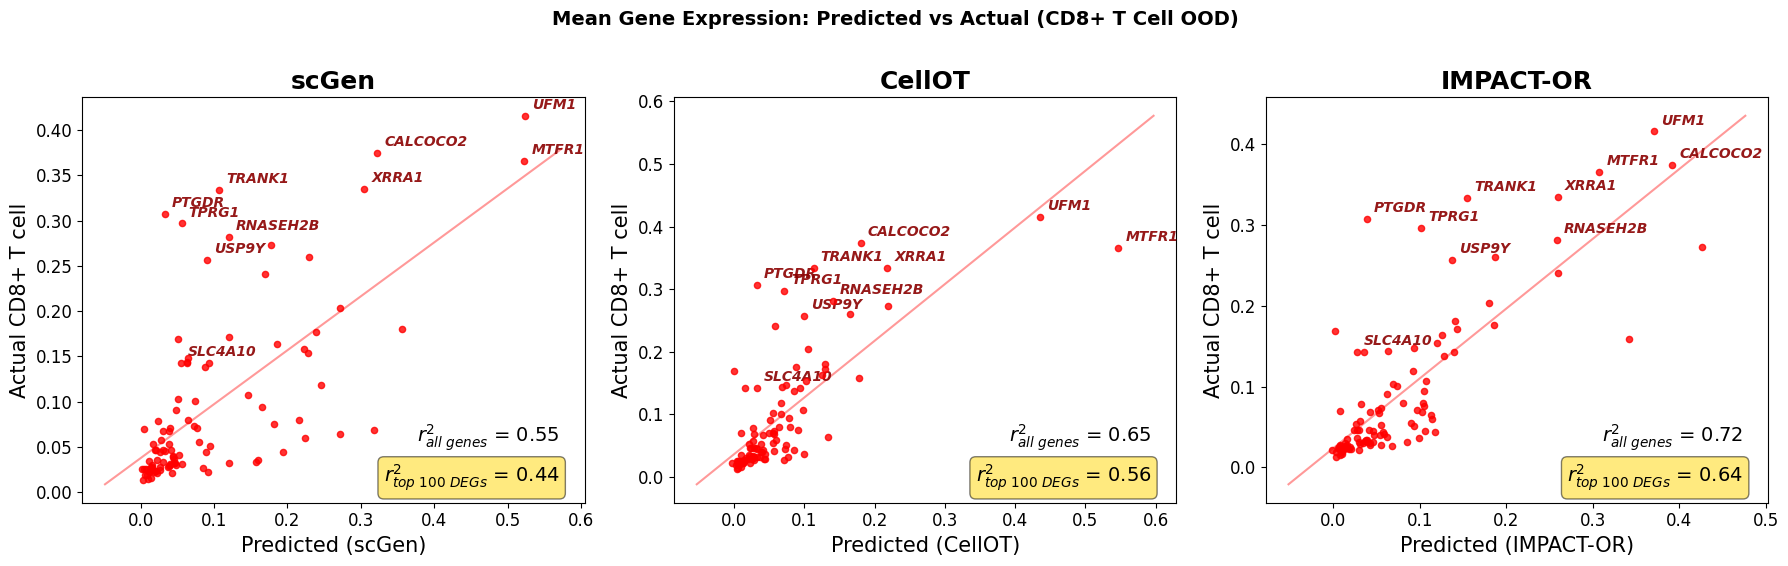

Saved: /n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/results/speciesot_cd8/r2_scatter_cd8_ood.png


In [81]:
# ==========================================================================
# GRAPH 2: R-squared Scatter Plot (imitating scGen paper Fig 2b)
# Predicted vs actual mean gene expression, with top DEGs highlighted
# ==========================================================================
treated_df = pd.DataFrame(to_dense(target_cd8.X), columns=target_cd8.var_names)
actual_means = treated_df.mean(0)

# Identify top 100 DEGs (genes with highest variance across the ground truth)
gene_var = treated_df.var(0)
top_100_degs = gene_var.nlargest(100).index.tolist()

# Collect predicted means for each model
predicted_means = {}
predicted_means['scGen'] = pd.DataFrame(
    to_dense(scgen_imputed.X), columns=scgen_imputed.var_names
).mean(0)

if (CELLOT_DIR / 'evals_ood_data_space/imputed.h5ad').exists():
    imp_s = anndata.read_h5ad(CELLOT_DIR / 'evals_ood_data_space/imputed.h5ad')
    predicted_means['CellOT'] = pd.DataFrame(
        to_dense(imp_s.X), columns=imp_s.var_names
    ).mean(0)

if (IMPACT_OR_DIR / 'evals_ood_data_space/imputed.h5ad').exists():
    imp_u = anndata.read_h5ad(IMPACT_OR_DIR / 'evals_ood_data_space/imputed.h5ad')
    predicted_means['IMPACT-OR'] = pd.DataFrame(
        to_dense(imp_u.X), columns=imp_u.var_names
    ).mean(0)

n_models = len(predicted_means)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5.5))
if n_models == 1:
    axes = [axes]

# Top 10 DEGs for labeling (by variance) — convert Ensembl IDs to gene symbols
top_10_degs = gene_var.nlargest(10).index.tolist()

try:
    import mygene
    mg = mygene.MyGeneInfo()
    results = mg.querymany(top_10_degs, scopes='ensembl.gene', fields='symbol', species='human', as_dataframe=False, verbose=False)
    ensembl_to_symbol = {r['query']: r.get('symbol', r['query']) for r in results if not r.get('notfound', False)}
except Exception:
    ensembl_to_symbol = {}

def gene_label(ensembl_id):
    return ensembl_to_symbol.get(ensembl_id, ensembl_id)

print(f"Top 10 DEG labels: {[gene_label(g) for g in top_10_degs]}")

for ax, (model_name, pred) in zip(axes, predicted_means.items()):
    shared = actual_means.index.intersection(pred.index)
    x_all = pred[shared].values
    y_all = actual_means[shared].values

    is_deg = np.array([g in top_100_degs for g in shared])
    is_top10 = np.array([g in top_10_degs for g in shared])

    r_all = np.corrcoef(x_all, y_all)[0, 1]
    r2_all_val = r_all ** 2
    r_deg = np.corrcoef(x_all[is_deg], y_all[is_deg])[0, 1] if is_deg.sum() > 2 else 0
    r2_deg_val = r_deg ** 2

    # Only plot top 100 DEG dots (red)
    ax.scatter(x_all[is_deg], y_all[is_deg], s=20, alpha=0.8, c='red', zorder=5)

    lims = [min(x_all[is_deg].min(), y_all[is_deg].min()) - 0.05,
            max(x_all[is_deg].max(), y_all[is_deg].max()) + 0.05]

    # Fit line through DEG points
    from numpy.polynomial.polynomial import polyfit
    b, m = polyfit(x_all[is_deg], y_all[is_deg], 1)
    xs = np.linspace(lims[0], lims[1], 100)
    ax.plot(xs, b + m * xs, color='red', alpha=0.4, linewidth=1.5)

    # Label top 10 DEGs
    shared_list = list(shared)
    for i, g in enumerate(shared_list):
        if g in top_10_degs:
            ax.annotate(gene_label(g), (x_all[i], y_all[i]), fontsize=10, alpha=0.9,
                        xytext=(5, 5), textcoords='offset points',
                        color='darkred', fontweight='bold', fontstyle='italic')

    ax.set_xlabel(f'Predicted ({model_name})', fontsize=15)
    ax.set_ylabel('Actual CD8+ T cell', fontsize=15)
    ax.set_title(model_name, fontsize=18, fontweight='bold')
    ax.tick_params(labelsize=12)

    # r² annotations
    ax.text(0.95, 0.15, f'$r^2_{{all\\ genes}}$ = {r2_all_val:.2f}',
            transform=ax.transAxes, ha='right', fontsize=14)
    ax.text(0.95, 0.05, f'$r^2_{{top\\ 100\\ DEGs}}$ = {r2_deg_val:.2f}',
            transform=ax.transAxes, ha='right', fontsize=14,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='gold', alpha=0.5))

plt.suptitle('Mean Gene Expression: Predicted vs Actual (CD8+ T Cell OOD)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(str(RESULTS / 'r2_scatter_cd8_ood.png'), dpi=500, bbox_inches='tight')
plt.show()
print(f"Saved: {RESULTS / 'r2_scatter_cd8_ood.png'}")